In [1]:
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TerminateOnNaN, CSVLogger
from keras import backend as K
from keras.models import load_model
from math import ceil
import numpy as np
from matplotlib import pyplot as plt, patches
from sklearn.model_selection import train_test_split

from models.ssd7_custom import build_model
from models.ssd7_resnet_backbone import resnet_build_model
from models.ssd300_custom import ssd300_build_model
from loss_function.custom_loss import AOILoss
from custom_layers.GridCenters import GridCenters

from input_encoder_decoder.input_encoder import SSDInputEncoder
from input_encoder_decoder.output_decoder import decode_detections
from input_encoder_decoder.data_generator import DataGenerator

%matplotlib inline

2022-12-20 12:29:02.403844: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-12-20 12:29:03.093967: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/token/miniforge3/envs/tf/lib/
2022-12-20 12:29:03.094028: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/token/miniforge3/envs/tf/lib/
2022-12-20 12:29:03.094033: W tensorflow/compiler/tf2ten

In [2]:
img_height = 300 # Height of the input images
img_width = 300 # Width of the input images
img_channels = 3 # Number of color channels of the input images
intensity_mean = 127.5 # Set this to your preference (maybe `None`). The current settings transform the input pixel values to the interval `[-1,1]`.
intensity_range = 127.5 # Set this to your preference (maybe `None`). The current settings transform the input pixel values to the interval `[-1,1]`.
n_classes = 1 # Number of positive classes
normalize_coords = True # Whether or not the model is supposed to use coordinates relative to the image size
model_type = "ssd7"

In [3]:
K.clear_session()

if model_type == "ssd7":

    model = build_model(image_size=(img_height, img_width, img_channels),
                        n_classes=n_classes,
                        l2_regularization=0.005,
                        normalize_coords=normalize_coords,
                        subtract_mean=intensity_mean,
                        divide_by_stddev=intensity_range)
    
elif model_type == "resnet":
    
    model = resnet_build_model(image_size=(img_height, img_width, img_channels),
                                n_classes=n_classes,
                                l2_regularization=0.005,
                                normalize_coords=normalize_coords)
    
elif model_type == "ssd300":
    
    model = ssd300_build_model(image_size=(img_height, img_width, img_channels),
                        n_classes=n_classes,
                        l2_regularization=0.005,
                        normalize_coords=normalize_coords,
                        subtract_mean=intensity_mean,
                        divide_by_stddev=intensity_range)
    

adam = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)

aoi_loss = AOILoss(neg_pos_ratio=3, alpha=1.5)

model.compile(optimizer=adam, loss=aoi_loss.compute_loss)

2022-12-20 12:29:04.346070: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-12-20 12:29:04.353571: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-12-20 12:29:04.353736: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-12-20 12:29:04.354119: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorF

In [4]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 300, 300, 3  0           []                               
                                )]                                                                
                                                                                                  
 identity_layer (Lambda)        (None, 300, 300, 3)  0           ['input_2[0][0]']                
                                                                                                  
 input_mean_normalization (Lamb  (None, 300, 300, 3)  0          ['identity_layer[1][0]']         
 da)                                                                                              
                                                                                              

In [5]:
predictor_size = [model.get_layer('classes7').output_shape[1:3]]
print('Predictor Layer Dimensions: ', predictor_size)

encoder = SSDInputEncoder(img_height,
                          img_width,
                          n_classes,
                          predictor_sizes=predictor_size,
                          normalize_coords=True,
                          background_id=0)

generator = DataGenerator(parent_dir='/home/token/AOI_Project/Datasets/custom_generated', encoder=encoder)

X, y = generator.get_data()

Predictor Layer Dimensions:  [(4, 4)]
Generating image arrays and encoding labels:
Converting images to arrays...


100%|█████████████████████████████████████| 8000/8000 [00:03<00:00, 2178.72it/s]


Images as numpy:
(8000, 300, 300, 3)
Parsing ground truth labels from .csv


100%|█████████████████████████████████████| 8000/8000 [00:07<00:00, 1008.08it/s]


Unencoded labels:
8000
Encoded labels:
(8000, 16, 12)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print('Train dataset: ', X_train.shape)
print('Test dataset: ', X_test.shape)
print('Train labels: ', y_train.shape)
print('Test labels: ', y_test.shape)

Train dataset:  (6400, 300, 300, 3)
Test dataset:  (1600, 300, 300, 3)
Train labels:  (6400, 16, 12)
Test labels:  (1600, 16, 12)


In [7]:
model_checkpoint = ModelCheckpoint(filepath='checkpoints/ssd7_epoch-{epoch:02d}_loss-{loss:.4f}_val_loss-{val_loss:.4f}.h5',
                                   monitor='val_loss',
                                   verbose=1,
                                   save_best_only=True,
                                   save_weights_only=False,
                                   mode='auto',
                                   save_freq="epoch")

csv_logger = CSVLogger(filename='ssd7_training_log.csv',
                       separator=',',
                       append=True)

early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0.0,
                               patience=16,
                               verbose=1,
                               restore_best_weights=True)

reduce_learning_rate = ReduceLROnPlateau(monitor='val_loss',
                                         factor=0.5,
                                         patience=8,
                                         verbose=1,
                                         min_delta=0.001,
                                         cooldown=0,
                                         min_lr=0.00001)

callbacks = [#model_checkpoint,
             csv_logger,
             early_stopping,
             reduce_learning_rate]

In [8]:
batch_size = 32
initial_epoch   = 0
final_epoch     = 500
steps_per_epoch = 1000

history = model.fit(X_train,
                    y_train,
                    batch_size=batch_size,
                    #steps_per_epoch=steps_per_epoch,
                    epochs=final_epoch,
                    callbacks=callbacks,
                    validation_data=(X_test, y_test),
                    validation_steps=ceil(X_test.shape[0]/batch_size),
                    initial_epoch=initial_epoch)

2022-12-20 12:29:17.708424: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 1728000000 exceeds 10% of free system memory.
2022-12-20 12:29:18.795928: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 1728000000 exceeds 10% of free system memory.


Epoch 1/500
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


2022-12-20 12:29:20.717544: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8100
2022-12-20 12:29:21.161929: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-12-20 12:29:21.162307: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-12-20 12:29:21.162343: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:85] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2022-12-20 12:29:21.162767: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-12-20 12:29:21.162814: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:318] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


200/200 [==============================] - 19s 80ms/step - loss: 4.4920 - val_loss: 3.7462 - lr: 0.0010
Epoch 2/500
200/200 [==============================] - 15s 77ms/step - loss: 2.9354 - val_loss: 2.6181 - lr: 0.0010
Epoch 3/500
200/200 [==============================] - 16s 78ms/step - loss: 2.1552 - val_loss: 2.2377 - lr: 0.0010
Epoch 4/500
200/200 [==============================] - 15s 77ms/step - loss: 1.5527 - val_loss: 1.6491 - lr: 0.0010
Epoch 5/500
200/200 [==============================] - 15s 78ms/step - loss: 1.1136 - val_loss: 1.9607 - lr: 0.0010
Epoch 6/500
200/200 [==============================] - 15s 77ms/step - loss: 0.7996 - val_loss: 3.0051 - lr: 0.0010
Epoch 7/500
200/200 [==============================] - 15s 77ms/step - loss: 0.5831 - val_loss: 0.5823 - lr: 0.0010
Epoch 8/500
200/200 [==============================] - 16s 78ms/step - loss: 0.4367 - val_loss: 0.6593 - lr: 0.0010
Epoch 9/500
200/200 [==============================] - 16s 78ms/step - loss: 0.3365 

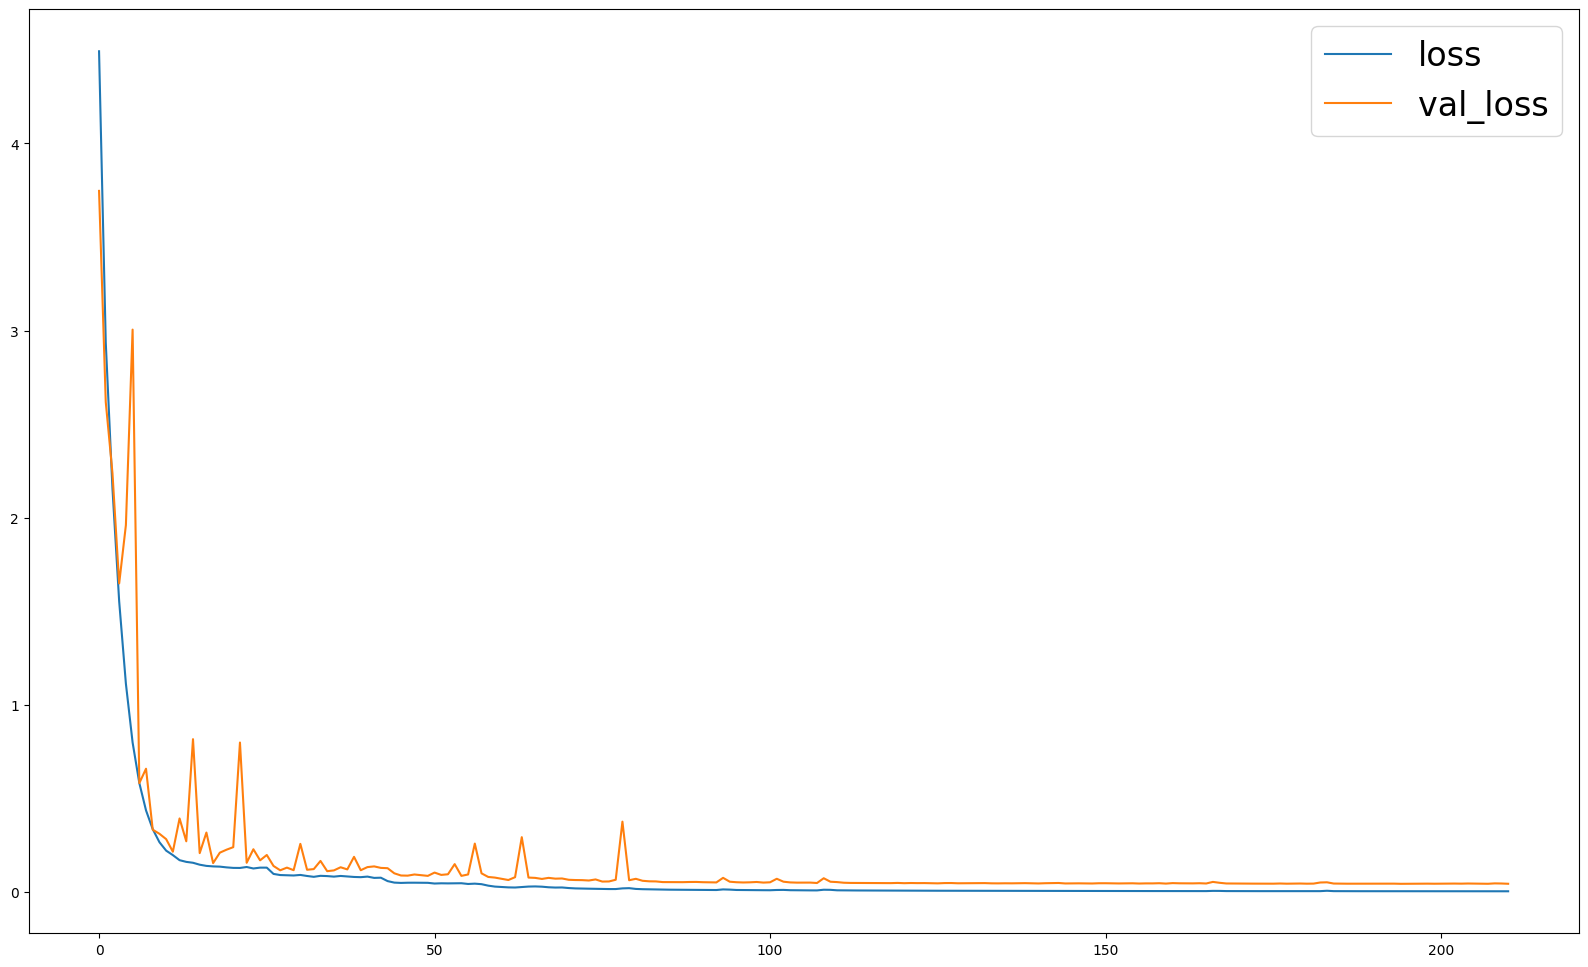

In [9]:
plt.figure(figsize=(20,12))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(loc='upper right', prop={'size': 24});

In [10]:
predictions = model.predict(X_test[:50])
print(predictions.shape)

2/2 [==============================] - 0s 277ms/step
(50, 16, 12)


In [11]:
decoded_pred = decode_detections(predictions, img_height=img_height, img_width=img_width)
print(decoded_pred[0])

[[  1.           0.9987845  129.26218     23.760843   207.60312
   21.813263   131.20572    102.09008    209.56186    100.173935  ]
 [  1.           0.98537934  42.962013   104.81863    119.578514
  111.58652     36.192085   181.41455    112.819115   188.21463   ]
 [  1.           0.99480814 167.44302    232.98315    199.47499
  232.43619    167.99364    264.99423    200.0274     264.4651    ]]


In [12]:
decoded_labels = decode_detections(y_test[:50], img_height=img_height, img_width=img_width)
print(decoded_labels[0])

[[  1.   1. 127.  22. 204.  21. 128.  99. 205.  98.]
 [  1.   1.  45. 108. 123. 115.  38. 186. 116. 193.]
 [  1.   1. 171. 231. 201. 232. 170. 261. 200. 262.]]


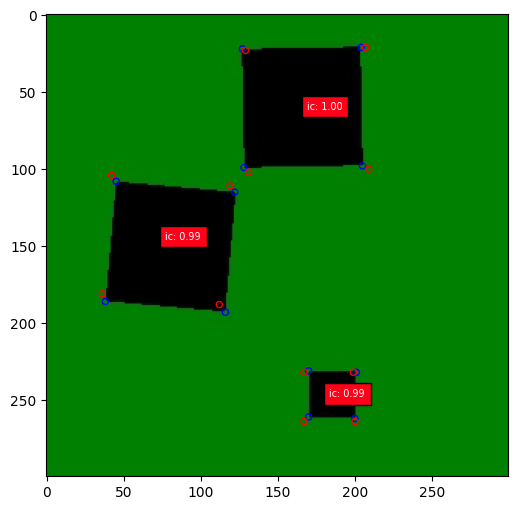

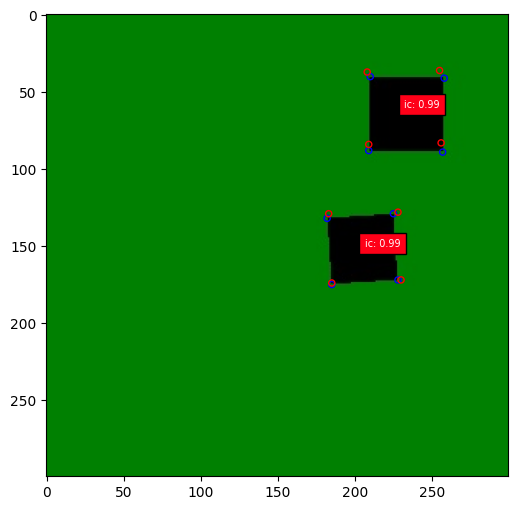

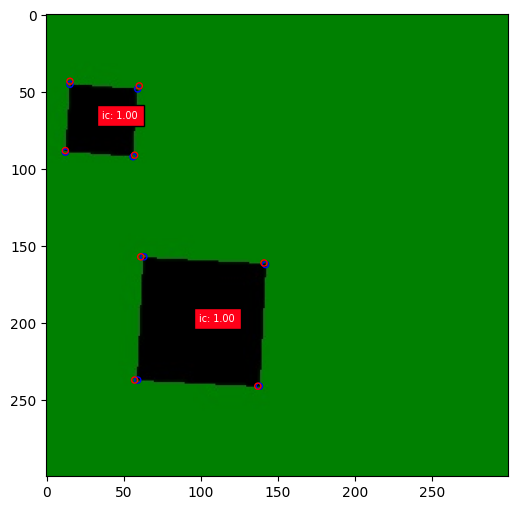

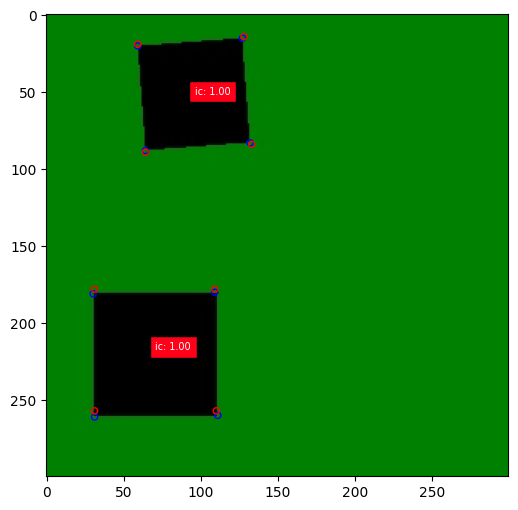

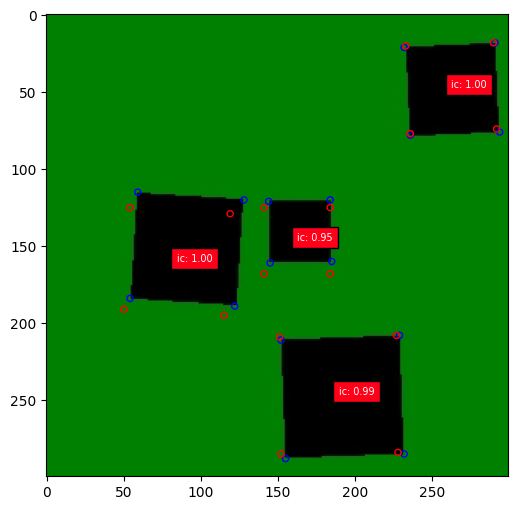

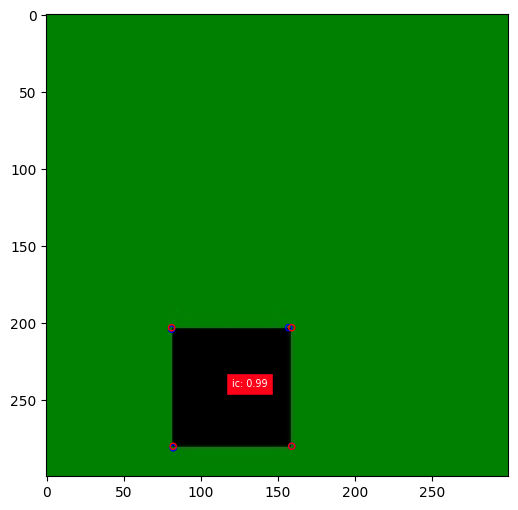

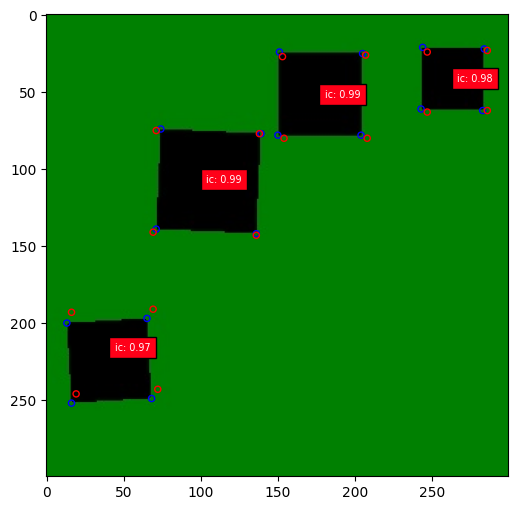

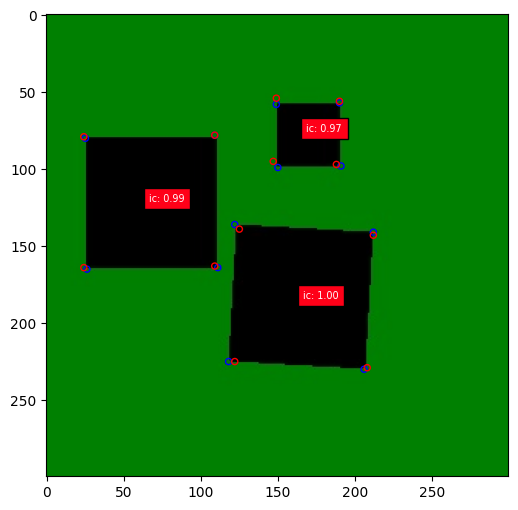

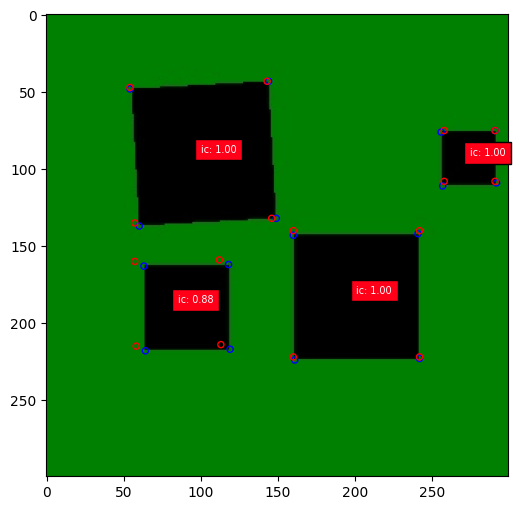

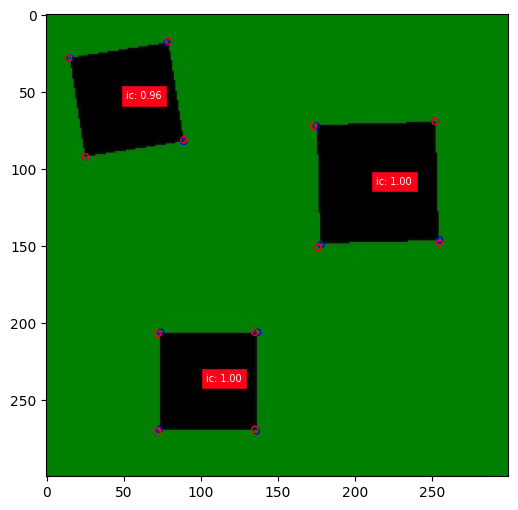

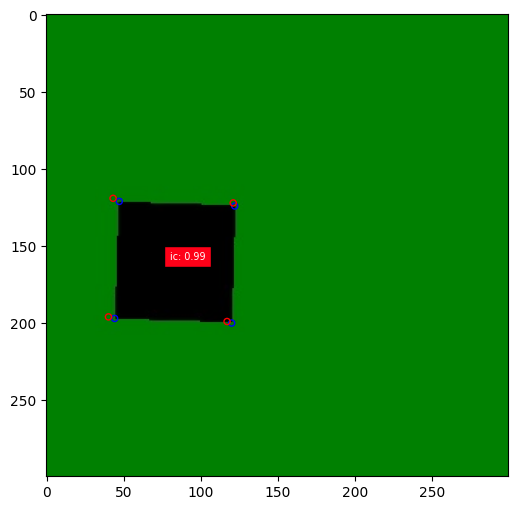

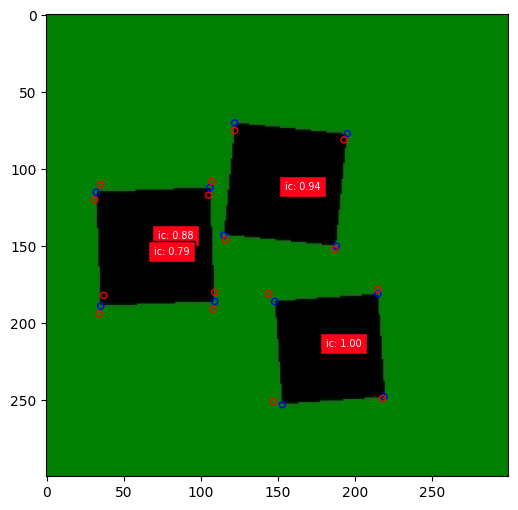

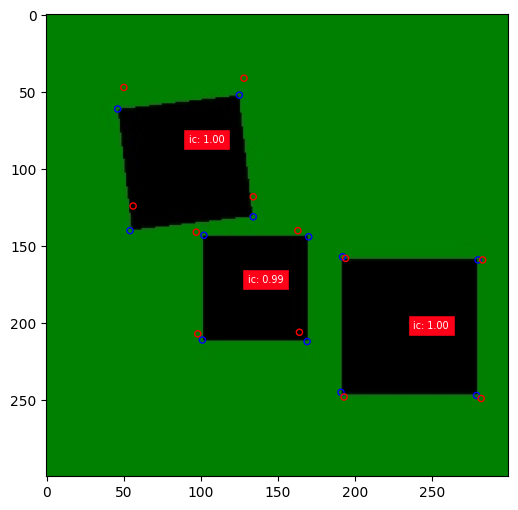

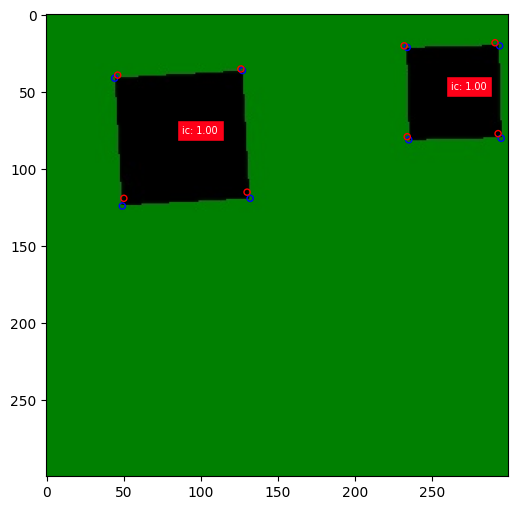

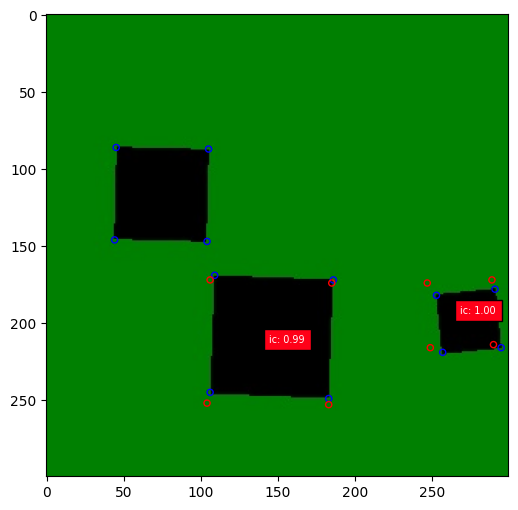

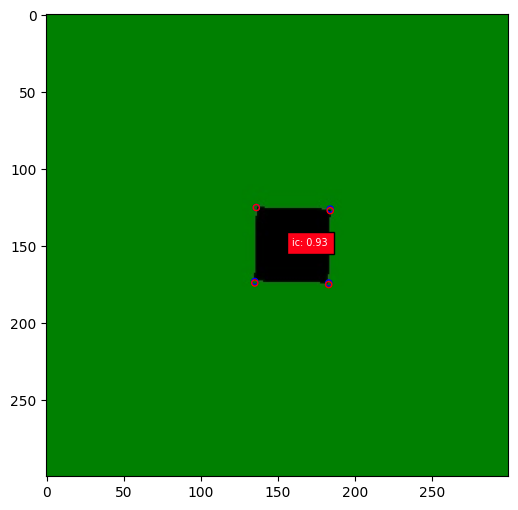

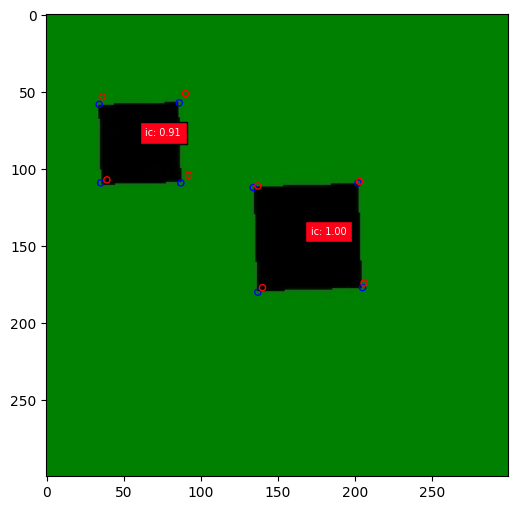

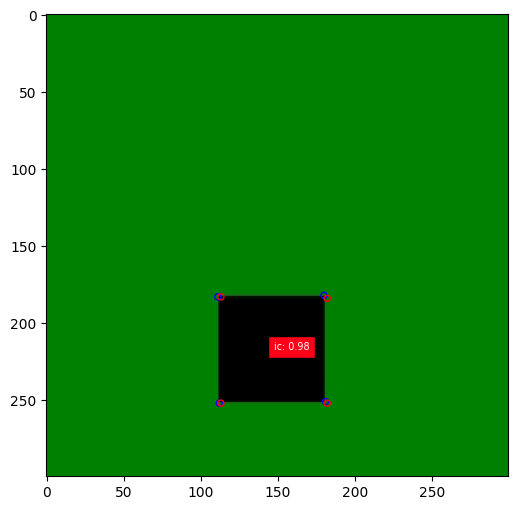

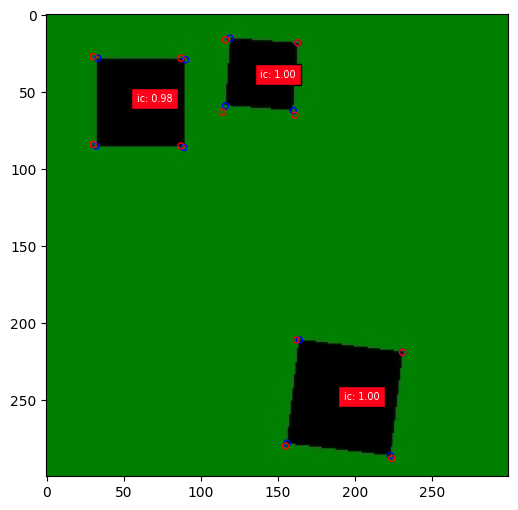

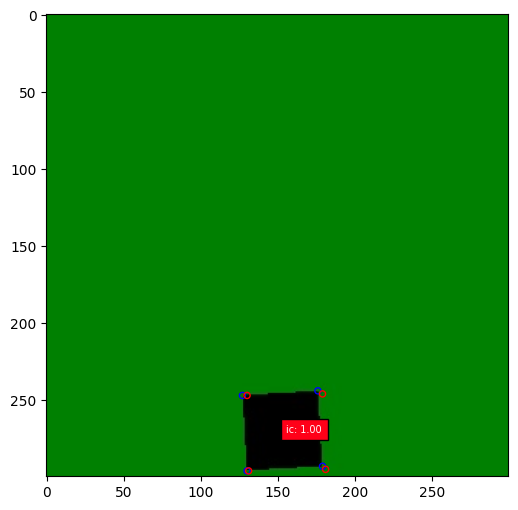

In [13]:
for i in range(len(decoded_pred[:20])):
    plt.figure(figsize=(10,6))
    plt.imshow(X_test[i])
    current_axis = plt.gca()

    colors = plt.cm.hsv(np.linspace(0, 1, n_classes+1)).tolist() # Set the colors for the bounding boxes
    classes = ['background', 'ic'] # Just so we can print class names onto the image instead of IDs
    
    for label in decoded_labels[i]:
        pred = np.array(label)
        corners = np.reshape(pred[2:], (-1, 2)).astype(int)
        color = colors[int(pred[0])]
        label = '{}'.format(classes[int(pred[0])])
        for points in corners:
            current_axis.add_patch(plt.Circle(tuple(points), 2, fill=False, color='blue'))
    
    for label in decoded_pred[i]:
        pred = np.array(label)
        corners = np.reshape(pred[2:], (-1, 2)).astype(int)
        color = colors[int(pred[0])]
        label = '{}: {:.2f}'.format(classes[int(pred[0])], pred[1])
        for points in corners:
            current_axis.add_patch(plt.Circle(tuple(points), 2, fill=False, color='red'))
        center_x = (corners[0, 0] + corners[3, 0]) / 2
        center_y = (corners[0, 1] + corners[3, 1]) / 2
        current_axis.text(center_x, center_y, label, size='x-small', color='white', bbox={'facecolor':color, 'alpha':1.0})
        